In [ ]:
# Get the name of the operating system
import platform
import os
import numpy as np
import pandas as pd
cwd = os.getcwd()

import matplotlib.pyplot as plt

system_name = platform.system()

if system_name == "Linux":
    parent_directory = os.path.join(cwd, '..')


pd.set_option("display.max_columns", None)

from helpers.dataframeBuilderBAQ import get_distances_indices_sklearn_NearestNeighbors
from helpers.dataframeBuilderBAQ import neighbors_distances_indices_to_readable_df
from helpers.dataframeBuilderBAQ import add_days_ago
from helpers.dataframeBuilderBAQ import add_version
from helpers.dataframeBuilderBAQ import add_candidate
from helpers.dataframeBuilderBAQ import load_df_candidate

NEIGBOURS=5

In [2]:
print(os.getcwd())

/home/miked/code/dep2-g2/anomalies/BAQ


In [3]:
df_candidate = load_df_candidate()
df_candidate

,CandidateKey,ID,InstanceID,Organisation,ChosenLanguage,ChosenGender,Gender,Qualification
0,14,1,4,B2BABE21-1705-4750-AE99-8D1316755876,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Male,Gender_Male,Qualification_Unknown
2,23,2,3,4B79F6DC-F833-4721-82E3-DF6F09AE8EA2,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,NaN,Gender_Male,Qualification_Unknown
10,62,6,2,FDE03D4F-9C9B-4B36-9C0C-F5296C6772F1,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Male,Gender_Male,Qualification_Bachelor
12,84,8,4,B2BABE21-1705-4750-AE99-8D1316755876,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Gender_Male,Gender_Male,Qualification_Unknown
14,94,9,4,B2BABE21-1705-4750-AE99-8D1316755876,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Male,Gender_Male,Qualification_Unknown
...,...,...,...,...,...,...,...,...
2292620,50830491,5083049,1,D4A15280-CD15-4298-A450-556703C30E00,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Male,Gender_Male,Qualification_Unknown
2292622,50830511,5083051,1,D4A15280-CD15-4298-A450-556703C30E00,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Male,Gender_Male,Qualification_Unknown
2292624,50830531,5083053,1,D4A15280-CD15-4298-A450-556703C30E00,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Male,Gender_Male,Qualification_Unknown
2292627,50830561,5083056,1,D4A15280-CD15-4298-A450-556703C30E00,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Male,Gender_Male,Qualification_Unknown


In [4]:
df = pd.read_csv("csv/preprocessed_data.csv")
df

,TestKey,Q0_A1_norm,Q0_A2_norm,Q0_A3_norm,Q0_A4_norm,Q0_A5_norm,Q1_A1_norm,Q1_A2_norm,Q1_A3_norm,Q1_A4_norm,Q1_A5_norm,Q2_A1_norm,Q2_A2_norm,Q2_A3_norm,Q2_A4_norm,Q2_A5_norm,Q3_A1_norm,Q3_A2_norm,Q3_A3_norm,Q3_A4_norm,Q3_A5_norm,Q4_A1_norm,Q4_A2_norm,Q4_A3_norm,Q4_A4_norm,Q4_A5_norm,Q5_A1_norm,Q5_A2_norm,Q5_A3_norm,Q5_A4_norm,Q5_A5_norm,Q6_A1_norm,Q6_A2_norm,Q6_A3_norm,Q6_A4_norm,Q6_A5_norm,Q7_A1_norm,Q7_A2_norm,Q7_A3_norm,Q7_A4_norm,Q7_A5_norm,Q8_A1_norm,Q8_A2_norm,Q8_A3_norm,Q8_A4_norm,Q8_A5_norm,Q9_A1_norm,Q9_A2_norm,Q9_A3_norm,Q9_A4_norm,Q9_A5_norm,Q10_A1_norm,Q10_A2_norm,Q10_A3_norm,Q10_A4_norm,Q10_A5_norm,Q11_A1_norm,Q11_A2_norm,Q11_A3_norm,Q11_A4_norm,Q11_A5_norm,Q12_A1_norm,Q12_A2_norm,Q12_A3_norm,Q12_A4_norm,Q12_A5_norm,Q13_A1_norm,Q13_A2_norm,Q13_A3_norm,Q13_A4_norm,Q13_A5_norm,Q14_A1_norm,Q14_A2_norm,Q14_A3_norm,Q14_A4_norm,Q14_A5_norm,Q15_A1_norm,Q15_A2_norm,Q15_A3_norm,Q15_A4_norm,Q15_A5_norm,Q16_A1_norm,Q16_A2_norm,Q16_A3_norm,Q16_A4_norm,Q16_A5_norm,Q17_A1_norm,Q17_A2_norm,Q17_A3_norm,Q17_A4_norm,Q17_A5_norm,Q18_A1_norm,Q18_A2_norm,Q18_A3_norm,Q18_A4_norm,Q18_A5_norm,Q19_A1_norm,Q19_A2_norm,Q19_A3_norm,Q19_A4_norm,Q19_A5_norm,Q20_A1_norm,Q20_A2_norm,Q20_A3_norm,Q20_A4_norm,Q20_A5_norm,Q21_A1_norm,Q21_A2_norm,Q21_A3_norm,Q21_A4_norm,Q21_A5_norm,Q22_A1_norm,Q22_A2_norm,Q22_A3_norm,Q22_A4_norm,Q22_A5_norm,Q23_A1_norm,Q23_A2_norm,Q23_A3_norm,Q23_A4_norm,Q23_A5_norm,Q24_A1_norm,Q24_A2_norm,Q24_A3_norm,Q24_A4_norm,Q24_A5_norm,Q25_A1_norm,Q25_A2_norm,Q25_A3_norm,Q25_A4_norm,Q25_A5_norm,Q26_A1_norm,Q26_A2_norm,Q26_A3_norm,Q26_A4_norm,Q26_A5_norm,Q27_A1_norm,Q27_A2_norm,Q27_A3_norm,Q27_A4_norm,Q27_A5_norm,Q28_A1_norm,Q28_A2_norm,Q28_A3_norm,Q28_A4_norm,Q28_A5_norm,Q29_A1_norm,Q29_A2_norm,Q29_A3_norm,Q29_A4_norm,Q29_A5_norm,Q30_A1_norm,Q30_A2_norm,Q30_A3_norm,Q30_A4_norm,Q30_A5_norm,Q31_A1_norm,Q31_A2_norm,Q31_A3_norm,Q31_A4_norm,Q31_A5_norm,Q32_A1_norm,Q32_A2_norm,Q32_A3_norm,Q32_A4_norm,Q32_A5_norm,Q33_A1_norm,Q33_A2_norm,Q33_A3_norm,Q33_A4_norm,Q33_A5_norm,Q34_A1_norm,Q34_A2_norm,Q34_A3_norm,Q34_A4_norm,Q34_A5_norm,Q35_A1_norm,Q35_A2_norm,Q35_A3_norm,Q35_A4_norm,Q35_A5_norm,Q36_A1_norm,Q36_A2_norm,Q36_A3_norm,Q36_A4_norm,Q36_A5_norm,Q37_A1_norm,Q37_A2_norm,Q37_A3_norm,Q37_A4_norm,Q37_A5_norm,Q38_A1_norm,Q38_A2_norm,Q38_A3_norm,Q38_A4_norm,Q38_A5_norm,Q39_A1_norm,Q39_A2_norm,Q39_A3_norm,Q39_A4_norm,Q39_A5_norm,Q40_A1_norm,Q40_A2_norm,Q40_A3_norm,Q40_A4_norm,Q40_A5_norm,Q41_A1_norm,Q41_A2_norm,Q41_A3_norm,Q41_A4_norm,Q41_A5_norm,Q42_A1_norm,Q42_A2_norm,Q42_A3_norm,Q42_A4_norm,Q42_A5_norm,Q43_A1_norm,Q43_A2_norm,Q43_A3_norm,Q43_A4_norm,Q43_A5_norm,Q44_A1_norm,Q44_A2_norm,Q44_A3_norm,Q44_A4_norm,Q44_A5_norm,Q46_A1_norm,Q46_A2_norm,Q46_A3_norm,Q46_A4_norm,Q46_A5_norm,Q47_A1_norm,Q47_A2_norm,Q47_A3_norm,Q47_A4_norm,Q47_A5_norm,Q48_A1_norm,Q48_A2_norm,Q48_A3_norm,Q48_A4_norm,Q48_A5_norm,Q49_A1_norm,Q49_A2_norm,Q49_A3_norm,Q49_A4_norm,Q49_A5_norm,Q51_A1_norm,Q51_A2_norm,Q51_A3_norm,Q51_A4_norm,Q51_A5_norm,Q52_A1_norm,Q52_A2_norm,Q52_A3_norm,Q52_A4_norm,Q52_A5_norm,Q53_A1_norm,Q53_A2_norm,Q53_A3_norm,Q53_A4_norm,Q53_A5_norm,Q54_A1_norm,Q54_A2_norm,Q54_A3_norm,Q54_A4_norm,Q54_A5_norm,Q56_A1_norm,Q56_A2_norm,Q56_A3_norm,Q56_A4_norm,Q56_A5_norm,Q57_A1_norm,Q57_A2_norm,Q57_A3_norm,Q57_A4_norm,Q57_A5_norm,Q58_A1_norm,Q58_A2_norm,Q58_A3_norm,Q58_A4_norm,Q58_A5_norm,Q59_A1_norm,Q59_A2_norm,Q59_A3_norm,Q59_A4_norm,Q59_A5_norm,Q61_A1_norm,Q61_A2_norm,Q61_A3_norm,Q61_A4_norm,Q61_A5_norm,Q62_A1_norm,Q62_A2_norm,Q62_A3_norm,Q62_A4_norm,Q62_A5_norm,Q63_A1_norm,Q63_A2_norm,Q63_A3_norm,Q63_A4_norm,Q63_A5_norm,Q0_A1_ips,Q0_A2_ips,Q0_A3_ips,Q0_A4_ips,Q0_A5_ips,Q1_A1_ips,Q1_A2_ips,Q1_A3_ips,Q1_A4_ips,Q1_A5_ips,Q2_A1_ips,Q2_A2_ips,Q2_A3_ips,Q2_A4_ips,Q2_A5_ips,Q3_A1_ips,Q3_A2_ips,Q3_A3_ips,Q3_A4_ips,Q3_A5_ips,Q4_A1_ips,Q4_A2_ips,Q4_A3_ips,Q4_A4_ips,Q4_A5_ips,Q5_A1_ips,Q5_A2_ips,Q5_A3_ips,Q5_A4_ips,Q5_A5_ips,Q6_A1_ips,Q6_A2_ips,Q6_A3_ips,Q6_A4_ips,Q6_A5_ips,Q7_A1_ips,Q7_A2_ips,Q7_A3_ips,Q7_A4_ips,Q7_A5_ips,Q8_A1_ips,Q8_A2_ips,Q8_A3_ips,Q8_A4_ips,Q

In [5]:
df.index = df["TestKey"]

In [6]:
df, df_test = add_days_ago(df)
df

,TestKey,Q0_A1_norm,Q0_A2_norm,Q0_A3_norm,Q0_A4_norm,Q0_A5_norm,Q1_A1_norm,Q1_A2_norm,Q1_A3_norm,Q1_A4_norm,Q1_A5_norm,Q2_A1_norm,Q2_A2_norm,Q2_A3_norm,Q2_A4_norm,Q2_A5_norm,Q3_A1_norm,Q3_A2_norm,Q3_A3_norm,Q3_A4_norm,Q3_A5_norm,Q4_A1_norm,Q4_A2_norm,Q4_A3_norm,Q4_A4_norm,Q4_A5_norm,Q5_A1_norm,Q5_A2_norm,Q5_A3_norm,Q5_A4_norm,Q5_A5_norm,Q6_A1_norm,Q6_A2_norm,Q6_A3_norm,Q6_A4_norm,Q6_A5_norm,Q7_A1_norm,Q7_A2_norm,Q7_A3_norm,Q7_A4_norm,Q7_A5_norm,Q8_A1_norm,Q8_A2_norm,Q8_A3_norm,Q8_A4_norm,Q8_A5_norm,Q9_A1_norm,Q9_A2_norm,Q9_A3_norm,Q9_A4_norm,Q9_A5_norm,Q10_A1_norm,Q10_A2_norm,Q10_A3_norm,Q10_A4_norm,Q10_A5_norm,Q11_A1_norm,Q11_A2_norm,Q11_A3_norm,Q11_A4_norm,Q11_A5_norm,Q12_A1_norm,Q12_A2_norm,Q12_A3_norm,Q12_A4_norm,Q12_A5_norm,Q13_A1_norm,Q13_A2_norm,Q13_A3_norm,Q13_A4_norm,Q13_A5_norm,Q14_A1_norm,Q14_A2_norm,Q14_A3_norm,Q14_A4_norm,Q14_A5_norm,Q15_A1_norm,Q15_A2_norm,Q15_A3_norm,Q15_A4_norm,Q15_A5_norm,Q16_A1_norm,Q16_A2_norm,Q16_A3_norm,Q16_A4_norm,Q16_A5_norm,Q17_A1_norm,Q17_A2_norm,Q17_A3_norm,Q17_A4_norm,Q17_A5_norm,Q18_A1_norm,Q18_A2_norm,Q18_A3_norm,Q18_A4_norm,Q18_A5_norm,Q19_A1_norm,Q19_A2_norm,Q19_A3_norm,Q19_A4_norm,Q19_A5_norm,Q20_A1_norm,Q20_A2_norm,Q20_A3_norm,Q20_A4_norm,Q20_A5_norm,Q21_A1_norm,Q21_A2_norm,Q21_A3_norm,Q21_A4_norm,Q21_A5_norm,Q22_A1_norm,Q22_A2_norm,Q22_A3_norm,Q22_A4_norm,Q22_A5_norm,Q23_A1_norm,Q23_A2_norm,Q23_A3_norm,Q23_A4_norm,Q23_A5_norm,Q24_A1_norm,Q24_A2_norm,Q24_A3_norm,Q24_A4_norm,Q24_A5_norm,Q25_A1_norm,Q25_A2_norm,Q25_A3_norm,Q25_A4_norm,Q25_A5_norm,Q26_A1_norm,Q26_A2_norm,Q26_A3_norm,Q26_A4_norm,Q26_A5_norm,Q27_A1_norm,Q27_A2_norm,Q27_A3_norm,Q27_A4_norm,Q27_A5_norm,Q28_A1_norm,Q28_A2_norm,Q28_A3_norm,Q28_A4_norm,Q28_A5_norm,Q29_A1_norm,Q29_A2_norm,Q29_A3_norm,Q29_A4_norm,Q29_A5_norm,Q30_A1_norm,Q30_A2_norm,Q30_A3_norm,Q30_A4_norm,Q30_A5_norm,Q31_A1_norm,Q31_A2_norm,Q31_A3_norm,Q31_A4_norm,Q31_A5_norm,Q32_A1_norm,Q32_A2_norm,Q32_A3_norm,Q32_A4_norm,Q32_A5_norm,Q33_A1_norm,Q33_A2_norm,Q33_A3_norm,Q33_A4_norm,Q33_A5_norm,Q34_A1_norm,Q34_A2_norm,Q34_A3_norm,Q34_A4_norm,Q34_A5_norm,Q35_A1_norm,Q35_A2_norm,Q35_A3_norm,Q35_A4_norm,Q35_A5_norm,Q36_A1_norm,Q36_A2_norm,Q36_A3_norm,Q36_A4_norm,Q36_A5_norm,Q37_A1_norm,Q37_A2_norm,Q37_A3_norm,Q37_A4_norm,Q37_A5_norm,Q38_A1_norm,Q38_A2_norm,Q38_A3_norm,Q38_A4_norm,Q38_A5_norm,Q39_A1_norm,Q39_A2_norm,Q39_A3_norm,Q39_A4_norm,Q39_A5_norm,Q40_A1_norm,Q40_A2_norm,Q40_A3_norm,Q40_A4_norm,Q40_A5_norm,Q41_A1_norm,Q41_A2_norm,Q41_A3_norm,Q41_A4_norm,Q41_A5_norm,Q42_A1_norm,Q42_A2_norm,Q42_A3_norm,Q42_A4_norm,Q42_A5_norm,Q43_A1_norm,Q43_A2_norm,Q43_A3_norm,Q43_A4_norm,Q43_A5_norm,Q44_A1_norm,Q44_A2_norm,Q44_A3_norm,Q44_A4_norm,Q44_A5_norm,Q46_A1_norm,Q46_A2_norm,Q46_A3_norm,Q46_A4_norm,Q46_A5_norm,Q47_A1_norm,Q47_A2_norm,Q47_A3_norm,Q47_A4_norm,Q47_A5_norm,Q48_A1_norm,Q48_A2_norm,Q48_A3_norm,Q48_A4_norm,Q48_A5_norm,Q49_A1_norm,Q49_A2_norm,Q49_A3_norm,Q49_A4_norm,Q49_A5_norm,Q51_A1_norm,Q51_A2_norm,Q51_A3_norm,Q51_A4_norm,Q51_A5_norm,Q52_A1_norm,Q52_A2_norm,Q52_A3_norm,Q52_A4_norm,Q52_A5_norm,Q53_A1_norm,Q53_A2_norm,Q53_A3_norm,Q53_A4_norm,Q53_A5_norm,Q54_A1_norm,Q54_A2_norm,Q54_A3_norm,Q54_A4_norm,Q54_A5_norm,Q56_A1_norm,Q56_A2_norm,Q56_A3_norm,Q56_A4_norm,Q56_A5_norm,Q57_A1_norm,Q57_A2_norm,Q57_A3_norm,Q57_A4_norm,Q57_A5_norm,Q58_A1_norm,Q58_A2_norm,Q58_A3_norm,Q58_A4_norm,Q58_A5_norm,Q59_A1_norm,Q59_A2_norm,Q59_A3_norm,Q59_A4_norm,Q59_A5_norm,Q61_A1_norm,Q61_A2_norm,Q61_A3_norm,Q61_A4_norm,Q61_A5_norm,Q62_A1_norm,Q62_A2_norm,Q62_A3_norm,Q62_A4_norm,Q62_A5_norm,Q63_A1_norm,Q63_A2_norm,Q63_A3_norm,Q63_A4_norm,Q63_A5_norm,Q0_A1_ips,Q0_A2_ips,Q0_A3_ips,Q0_A4_ips,Q0_A5_ips,Q1_A1_ips,Q1_A2_ips,Q1_A3_ips,Q1_A4_ips,Q1_A5_ips,Q2_A1_ips,Q2_A2_ips,Q2_A3_ips,Q2_A4_ips,Q2_A5_ips,Q3_A1_ips,Q3_A2_ips,Q3_A3_ips,Q3_A4_ips,Q3_A5_ips,Q4_A1_ips,Q4_A2_ips,Q4_A3_ips,Q4_A4_ips,Q4_A5_ips,Q5_A1_ips,Q5_A2_ips,Q5_A3_ips,Q5_A4_ips,Q5_A5_ips,Q6_A1_ips,Q6_A2_ips,Q6_A3_ips,Q6_A4_ips,Q6_A5_ips,Q7_A1_ips,Q7_A2_ips,Q7_A3_ips,Q7_A4_ips,Q7_A5_ips,Q8_A1_ips,Q8_A2_ips,Q8_A3_ips,Q8_A4_ips,Q

In [ ]:
# TODO : consider to drop, daysAgo = not filled in
df.loc[df[df["DaysAgo"] == 0].index, (df[df["DaysAgo"] == 0] != 0).any(axis=0)]

,Q1_A1_norm,Q1_A2_norm,Q1_A3_norm,Q1_A4_norm,Q1_A5_norm,Q1_A1_ips,Q1_A2_ips,Q1_A3_ips,Q1_A4_ips,Q1_A5_ips
TestKey,,,,,,,,,,
183639,2.0,3.0,5.0,1.0,4.0,2.0,3.0,4.0,1.0,5.0
183640,4.0,5.0,1.0,2.0,3.0,4.0,5.0,1.0,2.0,3.0
183641,4.0,5.0,2.0,1.0,3.0,5.0,4.0,2.0,1.0,3.0
183642,4.0,3.0,1.0,2.0,5.0,4.0,3.0,1.0,2.0,5.0
183643,1.0,5.0,4.0,2.0,3.0,1.0,5.0,4.0,2.0,3.0
...,...,...,...,...,...,...,...,...,...,...
183862,5.0,4.0,1.0,3.0,2.0,5.0,4.0,1.0,3.0,2.0
183872,1.0,4.0,5.0,2.0,3.0,1.0,4.0,5.0,2.0,3.0
183954,5.0,1.0,4.0,3.0,2.0,5.0,1.0,4.0,3.0,2.0


In [8]:
df = add_candidate(df, df_test=df_test)
df = add_version(df, df_test=df_test, one_hot=True)
df

VersionNumber
v2.0    9830
v2.1    5295
v1.0    3562
v1.2    1858
v1.1     578
Name: count, dtype: int64


,TestKey,Q0_A1_norm,Q0_A2_norm,Q0_A3_norm,Q0_A4_norm,Q0_A5_norm,Q1_A1_norm,Q1_A2_norm,Q1_A3_norm,Q1_A4_norm,Q1_A5_norm,Q2_A1_norm,Q2_A2_norm,Q2_A3_norm,Q2_A4_norm,Q2_A5_norm,Q3_A1_norm,Q3_A2_norm,Q3_A3_norm,Q3_A4_norm,Q3_A5_norm,Q4_A1_norm,Q4_A2_norm,Q4_A3_norm,Q4_A4_norm,Q4_A5_norm,Q5_A1_norm,Q5_A2_norm,Q5_A3_norm,Q5_A4_norm,Q5_A5_norm,Q6_A1_norm,Q6_A2_norm,Q6_A3_norm,Q6_A4_norm,Q6_A5_norm,Q7_A1_norm,Q7_A2_norm,Q7_A3_norm,Q7_A4_norm,Q7_A5_norm,Q8_A1_norm,Q8_A2_norm,Q8_A3_norm,Q8_A4_norm,Q8_A5_norm,Q9_A1_norm,Q9_A2_norm,Q9_A3_norm,Q9_A4_norm,Q9_A5_norm,Q10_A1_norm,Q10_A2_norm,Q10_A3_norm,Q10_A4_norm,Q10_A5_norm,Q11_A1_norm,Q11_A2_norm,Q11_A3_norm,Q11_A4_norm,Q11_A5_norm,Q12_A1_norm,Q12_A2_norm,Q12_A3_norm,Q12_A4_norm,Q12_A5_norm,Q13_A1_norm,Q13_A2_norm,Q13_A3_norm,Q13_A4_norm,Q13_A5_norm,Q14_A1_norm,Q14_A2_norm,Q14_A3_norm,Q14_A4_norm,Q14_A5_norm,Q15_A1_norm,Q15_A2_norm,Q15_A3_norm,Q15_A4_norm,Q15_A5_norm,Q16_A1_norm,Q16_A2_norm,Q16_A3_norm,Q16_A4_norm,Q16_A5_norm,Q17_A1_norm,Q17_A2_norm,Q17_A3_norm,Q17_A4_norm,Q17_A5_norm,Q18_A1_norm,Q18_A2_norm,Q18_A3_norm,Q18_A4_norm,Q18_A5_norm,Q19_A1_norm,Q19_A2_norm,Q19_A3_norm,Q19_A4_norm,Q19_A5_norm,Q20_A1_norm,Q20_A2_norm,Q20_A3_norm,Q20_A4_norm,Q20_A5_norm,Q21_A1_norm,Q21_A2_norm,Q21_A3_norm,Q21_A4_norm,Q21_A5_norm,Q22_A1_norm,Q22_A2_norm,Q22_A3_norm,Q22_A4_norm,Q22_A5_norm,Q23_A1_norm,Q23_A2_norm,Q23_A3_norm,Q23_A4_norm,Q23_A5_norm,Q24_A1_norm,Q24_A2_norm,Q24_A3_norm,Q24_A4_norm,Q24_A5_norm,Q25_A1_norm,Q25_A2_norm,Q25_A3_norm,Q25_A4_norm,Q25_A5_norm,Q26_A1_norm,Q26_A2_norm,Q26_A3_norm,Q26_A4_norm,Q26_A5_norm,Q27_A1_norm,Q27_A2_norm,Q27_A3_norm,Q27_A4_norm,Q27_A5_norm,Q28_A1_norm,Q28_A2_norm,Q28_A3_norm,Q28_A4_norm,Q28_A5_norm,Q29_A1_norm,Q29_A2_norm,Q29_A3_norm,Q29_A4_norm,Q29_A5_norm,Q30_A1_norm,Q30_A2_norm,Q30_A3_norm,Q30_A4_norm,Q30_A5_norm,Q31_A1_norm,Q31_A2_norm,Q31_A3_norm,Q31_A4_norm,Q31_A5_norm,Q32_A1_norm,Q32_A2_norm,Q32_A3_norm,Q32_A4_norm,Q32_A5_norm,Q33_A1_norm,Q33_A2_norm,Q33_A3_norm,Q33_A4_norm,Q33_A5_norm,Q34_A1_norm,Q34_A2_norm,Q34_A3_norm,Q34_A4_norm,Q34_A5_norm,Q35_A1_norm,Q35_A2_norm,Q35_A3_norm,Q35_A4_norm,Q35_A5_norm,Q36_A1_norm,Q36_A2_norm,Q36_A3_norm,Q36_A4_norm,Q36_A5_norm,Q37_A1_norm,Q37_A2_norm,Q37_A3_norm,Q37_A4_norm,Q37_A5_norm,Q38_A1_norm,Q38_A2_norm,Q38_A3_norm,Q38_A4_norm,Q38_A5_norm,Q39_A1_norm,Q39_A2_norm,Q39_A3_norm,Q39_A4_norm,Q39_A5_norm,Q40_A1_norm,Q40_A2_norm,Q40_A3_norm,Q40_A4_norm,Q40_A5_norm,Q41_A1_norm,Q41_A2_norm,Q41_A3_norm,Q41_A4_norm,Q41_A5_norm,Q42_A1_norm,Q42_A2_norm,Q42_A3_norm,Q42_A4_norm,Q42_A5_norm,Q43_A1_norm,Q43_A2_norm,Q43_A3_norm,Q43_A4_norm,Q43_A5_norm,Q44_A1_norm,Q44_A2_norm,Q44_A3_norm,Q44_A4_norm,Q44_A5_norm,Q46_A1_norm,Q46_A2_norm,Q46_A3_norm,Q46_A4_norm,Q46_A5_norm,Q47_A1_norm,Q47_A2_norm,Q47_A3_norm,Q47_A4_norm,Q47_A5_norm,Q48_A1_norm,Q48_A2_norm,Q48_A3_norm,Q48_A4_norm,Q48_A5_norm,Q49_A1_norm,Q49_A2_norm,Q49_A3_norm,Q49_A4_norm,Q49_A5_norm,Q51_A1_norm,Q51_A2_norm,Q51_A3_norm,Q51_A4_norm,Q51_A5_norm,Q52_A1_norm,Q52_A2_norm,Q52_A3_norm,Q52_A4_norm,Q52_A5_norm,Q53_A1_norm,Q53_A2_norm,Q53_A3_norm,Q53_A4_norm,Q53_A5_norm,Q54_A1_norm,Q54_A2_norm,Q54_A3_norm,Q54_A4_norm,Q54_A5_norm,Q56_A1_norm,Q56_A2_norm,Q56_A3_norm,Q56_A4_norm,Q56_A5_norm,Q57_A1_norm,Q57_A2_norm,Q57_A3_norm,Q57_A4_norm,Q57_A5_norm,Q58_A1_norm,Q58_A2_norm,Q58_A3_norm,Q58_A4_norm,Q58_A5_norm,Q59_A1_norm,Q59_A2_norm,Q59_A3_norm,Q59_A4_norm,Q59_A5_norm,Q61_A1_norm,Q61_A2_norm,Q61_A3_norm,Q61_A4_norm,Q61_A5_norm,Q62_A1_norm,Q62_A2_norm,Q62_A3_norm,Q62_A4_norm,Q62_A5_norm,Q63_A1_norm,Q63_A2_norm,Q63_A3_norm,Q63_A4_norm,Q63_A5_norm,Q0_A1_ips,Q0_A2_ips,Q0_A3_ips,Q0_A4_ips,Q0_A5_ips,Q1_A1_ips,Q1_A2_ips,Q1_A3_ips,Q1_A4_ips,Q1_A5_ips,Q2_A1_ips,Q2_A2_ips,Q2_A3_ips,Q2_A4_ips,Q2_A5_ips,Q3_A1_ips,Q3_A2_ips,Q3_A3_ips,Q3_A4_ips,Q3_A5_ips,Q4_A1_ips,Q4_A2_ips,Q4_A3_ips,Q4_A4_ips,Q4_A5_ips,Q5_A1_ips,Q5_A2_ips,Q5_A3_ips,Q5_A4_ips,Q5_A5_ips,Q6_A1_ips,Q6_A2_ips,Q6_A3_ips,Q6_A4_ips,Q6_A5_ips,Q7_A1_ips,Q7_A2_ips,Q7_A3_ips,Q7_A4_ips,Q7_A5_ips,Q8_A1_ips,Q8_A2_ips,Q8_A3_ips,Q8_A4_ips,Q

In [9]:
# For neighbours, multiply versions by 10 to increase distance.
WEIGHT = 10
df["VersionNumber_v1.0"] = WEIGHT * df["VersionNumber_v1.0"]
df["VersionNumber_v1.1"] = WEIGHT * df["VersionNumber_v1.1"]
df["VersionNumber_v1.2"] = WEIGHT * df["VersionNumber_v1.2"]
df["VersionNumber_v2.0"] = WEIGHT * df["VersionNumber_v2.0"]
df["VersionNumber_v2.1"] = WEIGHT * df["VersionNumber_v2.1"]
df

,TestKey,Q0_A1_norm,Q0_A2_norm,Q0_A3_norm,Q0_A4_norm,Q0_A5_norm,Q1_A1_norm,Q1_A2_norm,Q1_A3_norm,Q1_A4_norm,Q1_A5_norm,Q2_A1_norm,Q2_A2_norm,Q2_A3_norm,Q2_A4_norm,Q2_A5_norm,Q3_A1_norm,Q3_A2_norm,Q3_A3_norm,Q3_A4_norm,Q3_A5_norm,Q4_A1_norm,Q4_A2_norm,Q4_A3_norm,Q4_A4_norm,Q4_A5_norm,Q5_A1_norm,Q5_A2_norm,Q5_A3_norm,Q5_A4_norm,Q5_A5_norm,Q6_A1_norm,Q6_A2_norm,Q6_A3_norm,Q6_A4_norm,Q6_A5_norm,Q7_A1_norm,Q7_A2_norm,Q7_A3_norm,Q7_A4_norm,Q7_A5_norm,Q8_A1_norm,Q8_A2_norm,Q8_A3_norm,Q8_A4_norm,Q8_A5_norm,Q9_A1_norm,Q9_A2_norm,Q9_A3_norm,Q9_A4_norm,Q9_A5_norm,Q10_A1_norm,Q10_A2_norm,Q10_A3_norm,Q10_A4_norm,Q10_A5_norm,Q11_A1_norm,Q11_A2_norm,Q11_A3_norm,Q11_A4_norm,Q11_A5_norm,Q12_A1_norm,Q12_A2_norm,Q12_A3_norm,Q12_A4_norm,Q12_A5_norm,Q13_A1_norm,Q13_A2_norm,Q13_A3_norm,Q13_A4_norm,Q13_A5_norm,Q14_A1_norm,Q14_A2_norm,Q14_A3_norm,Q14_A4_norm,Q14_A5_norm,Q15_A1_norm,Q15_A2_norm,Q15_A3_norm,Q15_A4_norm,Q15_A5_norm,Q16_A1_norm,Q16_A2_norm,Q16_A3_norm,Q16_A4_norm,Q16_A5_norm,Q17_A1_norm,Q17_A2_norm,Q17_A3_norm,Q17_A4_norm,Q17_A5_norm,Q18_A1_norm,Q18_A2_norm,Q18_A3_norm,Q18_A4_norm,Q18_A5_norm,Q19_A1_norm,Q19_A2_norm,Q19_A3_norm,Q19_A4_norm,Q19_A5_norm,Q20_A1_norm,Q20_A2_norm,Q20_A3_norm,Q20_A4_norm,Q20_A5_norm,Q21_A1_norm,Q21_A2_norm,Q21_A3_norm,Q21_A4_norm,Q21_A5_norm,Q22_A1_norm,Q22_A2_norm,Q22_A3_norm,Q22_A4_norm,Q22_A5_norm,Q23_A1_norm,Q23_A2_norm,Q23_A3_norm,Q23_A4_norm,Q23_A5_norm,Q24_A1_norm,Q24_A2_norm,Q24_A3_norm,Q24_A4_norm,Q24_A5_norm,Q25_A1_norm,Q25_A2_norm,Q25_A3_norm,Q25_A4_norm,Q25_A5_norm,Q26_A1_norm,Q26_A2_norm,Q26_A3_norm,Q26_A4_norm,Q26_A5_norm,Q27_A1_norm,Q27_A2_norm,Q27_A3_norm,Q27_A4_norm,Q27_A5_norm,Q28_A1_norm,Q28_A2_norm,Q28_A3_norm,Q28_A4_norm,Q28_A5_norm,Q29_A1_norm,Q29_A2_norm,Q29_A3_norm,Q29_A4_norm,Q29_A5_norm,Q30_A1_norm,Q30_A2_norm,Q30_A3_norm,Q30_A4_norm,Q30_A5_norm,Q31_A1_norm,Q31_A2_norm,Q31_A3_norm,Q31_A4_norm,Q31_A5_norm,Q32_A1_norm,Q32_A2_norm,Q32_A3_norm,Q32_A4_norm,Q32_A5_norm,Q33_A1_norm,Q33_A2_norm,Q33_A3_norm,Q33_A4_norm,Q33_A5_norm,Q34_A1_norm,Q34_A2_norm,Q34_A3_norm,Q34_A4_norm,Q34_A5_norm,Q35_A1_norm,Q35_A2_norm,Q35_A3_norm,Q35_A4_norm,Q35_A5_norm,Q36_A1_norm,Q36_A2_norm,Q36_A3_norm,Q36_A4_norm,Q36_A5_norm,Q37_A1_norm,Q37_A2_norm,Q37_A3_norm,Q37_A4_norm,Q37_A5_norm,Q38_A1_norm,Q38_A2_norm,Q38_A3_norm,Q38_A4_norm,Q38_A5_norm,Q39_A1_norm,Q39_A2_norm,Q39_A3_norm,Q39_A4_norm,Q39_A5_norm,Q40_A1_norm,Q40_A2_norm,Q40_A3_norm,Q40_A4_norm,Q40_A5_norm,Q41_A1_norm,Q41_A2_norm,Q41_A3_norm,Q41_A4_norm,Q41_A5_norm,Q42_A1_norm,Q42_A2_norm,Q42_A3_norm,Q42_A4_norm,Q42_A5_norm,Q43_A1_norm,Q43_A2_norm,Q43_A3_norm,Q43_A4_norm,Q43_A5_norm,Q44_A1_norm,Q44_A2_norm,Q44_A3_norm,Q44_A4_norm,Q44_A5_norm,Q46_A1_norm,Q46_A2_norm,Q46_A3_norm,Q46_A4_norm,Q46_A5_norm,Q47_A1_norm,Q47_A2_norm,Q47_A3_norm,Q47_A4_norm,Q47_A5_norm,Q48_A1_norm,Q48_A2_norm,Q48_A3_norm,Q48_A4_norm,Q48_A5_norm,Q49_A1_norm,Q49_A2_norm,Q49_A3_norm,Q49_A4_norm,Q49_A5_norm,Q51_A1_norm,Q51_A2_norm,Q51_A3_norm,Q51_A4_norm,Q51_A5_norm,Q52_A1_norm,Q52_A2_norm,Q52_A3_norm,Q52_A4_norm,Q52_A5_norm,Q53_A1_norm,Q53_A2_norm,Q53_A3_norm,Q53_A4_norm,Q53_A5_norm,Q54_A1_norm,Q54_A2_norm,Q54_A3_norm,Q54_A4_norm,Q54_A5_norm,Q56_A1_norm,Q56_A2_norm,Q56_A3_norm,Q56_A4_norm,Q56_A5_norm,Q57_A1_norm,Q57_A2_norm,Q57_A3_norm,Q57_A4_norm,Q57_A5_norm,Q58_A1_norm,Q58_A2_norm,Q58_A3_norm,Q58_A4_norm,Q58_A5_norm,Q59_A1_norm,Q59_A2_norm,Q59_A3_norm,Q59_A4_norm,Q59_A5_norm,Q61_A1_norm,Q61_A2_norm,Q61_A3_norm,Q61_A4_norm,Q61_A5_norm,Q62_A1_norm,Q62_A2_norm,Q62_A3_norm,Q62_A4_norm,Q62_A5_norm,Q63_A1_norm,Q63_A2_norm,Q63_A3_norm,Q63_A4_norm,Q63_A5_norm,Q0_A1_ips,Q0_A2_ips,Q0_A3_ips,Q0_A4_ips,Q0_A5_ips,Q1_A1_ips,Q1_A2_ips,Q1_A3_ips,Q1_A4_ips,Q1_A5_ips,Q2_A1_ips,Q2_A2_ips,Q2_A3_ips,Q2_A4_ips,Q2_A5_ips,Q3_A1_ips,Q3_A2_ips,Q3_A3_ips,Q3_A4_ips,Q3_A5_ips,Q4_A1_ips,Q4_A2_ips,Q4_A3_ips,Q4_A4_ips,Q4_A5_ips,Q5_A1_ips,Q5_A2_ips,Q5_A3_ips,Q5_A4_ips,Q5_A5_ips,Q6_A1_ips,Q6_A2_ips,Q6_A3_ips,Q6_A4_ips,Q6_A5_ips,Q7_A1_ips,Q7_A2_ips,Q7_A3_ips,Q7_A4_ips,Q7_A5_ips,Q8_A1_ips,Q8_A2_ips,Q8_A3_ips,Q8_A4_ips,Q

In [10]:
df.drop(columns="TestKey", inplace=True)

In [11]:
df

,Q0_A1_norm,Q0_A2_norm,Q0_A3_norm,Q0_A4_norm,Q0_A5_norm,Q1_A1_norm,Q1_A2_norm,Q1_A3_norm,Q1_A4_norm,Q1_A5_norm,Q2_A1_norm,Q2_A2_norm,Q2_A3_norm,Q2_A4_norm,Q2_A5_norm,Q3_A1_norm,Q3_A2_norm,Q3_A3_norm,Q3_A4_norm,Q3_A5_norm,Q4_A1_norm,Q4_A2_norm,Q4_A3_norm,Q4_A4_norm,Q4_A5_norm,Q5_A1_norm,Q5_A2_norm,Q5_A3_norm,Q5_A4_norm,Q5_A5_norm,Q6_A1_norm,Q6_A2_norm,Q6_A3_norm,Q6_A4_norm,Q6_A5_norm,Q7_A1_norm,Q7_A2_norm,Q7_A3_norm,Q7_A4_norm,Q7_A5_norm,Q8_A1_norm,Q8_A2_norm,Q8_A3_norm,Q8_A4_norm,Q8_A5_norm,Q9_A1_norm,Q9_A2_norm,Q9_A3_norm,Q9_A4_norm,Q9_A5_norm,Q10_A1_norm,Q10_A2_norm,Q10_A3_norm,Q10_A4_norm,Q10_A5_norm,Q11_A1_norm,Q11_A2_norm,Q11_A3_norm,Q11_A4_norm,Q11_A5_norm,Q12_A1_norm,Q12_A2_norm,Q12_A3_norm,Q12_A4_norm,Q12_A5_norm,Q13_A1_norm,Q13_A2_norm,Q13_A3_norm,Q13_A4_norm,Q13_A5_norm,Q14_A1_norm,Q14_A2_norm,Q14_A3_norm,Q14_A4_norm,Q14_A5_norm,Q15_A1_norm,Q15_A2_norm,Q15_A3_norm,Q15_A4_norm,Q15_A5_norm,Q16_A1_norm,Q16_A2_norm,Q16_A3_norm,Q16_A4_norm,Q16_A5_norm,Q17_A1_norm,Q17_A2_norm,Q17_A3_norm,Q17_A4_norm,Q17_A5_norm,Q18_A1_norm,Q18_A2_norm,Q18_A3_norm,Q18_A4_norm,Q18_A5_norm,Q19_A1_norm,Q19_A2_norm,Q19_A3_norm,Q19_A4_norm,Q19_A5_norm,Q20_A1_norm,Q20_A2_norm,Q20_A3_norm,Q20_A4_norm,Q20_A5_norm,Q21_A1_norm,Q21_A2_norm,Q21_A3_norm,Q21_A4_norm,Q21_A5_norm,Q22_A1_norm,Q22_A2_norm,Q22_A3_norm,Q22_A4_norm,Q22_A5_norm,Q23_A1_norm,Q23_A2_norm,Q23_A3_norm,Q23_A4_norm,Q23_A5_norm,Q24_A1_norm,Q24_A2_norm,Q24_A3_norm,Q24_A4_norm,Q24_A5_norm,Q25_A1_norm,Q25_A2_norm,Q25_A3_norm,Q25_A4_norm,Q25_A5_norm,Q26_A1_norm,Q26_A2_norm,Q26_A3_norm,Q26_A4_norm,Q26_A5_norm,Q27_A1_norm,Q27_A2_norm,Q27_A3_norm,Q27_A4_norm,Q27_A5_norm,Q28_A1_norm,Q28_A2_norm,Q28_A3_norm,Q28_A4_norm,Q28_A5_norm,Q29_A1_norm,Q29_A2_norm,Q29_A3_norm,Q29_A4_norm,Q29_A5_norm,Q30_A1_norm,Q30_A2_norm,Q30_A3_norm,Q30_A4_norm,Q30_A5_norm,Q31_A1_norm,Q31_A2_norm,Q31_A3_norm,Q31_A4_norm,Q31_A5_norm,Q32_A1_norm,Q32_A2_norm,Q32_A3_norm,Q32_A4_norm,Q32_A5_norm,Q33_A1_norm,Q33_A2_norm,Q33_A3_norm,Q33_A4_norm,Q33_A5_norm,Q34_A1_norm,Q34_A2_norm,Q34_A3_norm,Q34_A4_norm,Q34_A5_norm,Q35_A1_norm,Q35_A2_norm,Q35_A3_norm,Q35_A4_norm,Q35_A5_norm,Q36_A1_norm,Q36_A2_norm,Q36_A3_norm,Q36_A4_norm,Q36_A5_norm,Q37_A1_norm,Q37_A2_norm,Q37_A3_norm,Q37_A4_norm,Q37_A5_norm,Q38_A1_norm,Q38_A2_norm,Q38_A3_norm,Q38_A4_norm,Q38_A5_norm,Q39_A1_norm,Q39_A2_norm,Q39_A3_norm,Q39_A4_norm,Q39_A5_norm,Q40_A1_norm,Q40_A2_norm,Q40_A3_norm,Q40_A4_norm,Q40_A5_norm,Q41_A1_norm,Q41_A2_norm,Q41_A3_norm,Q41_A4_norm,Q41_A5_norm,Q42_A1_norm,Q42_A2_norm,Q42_A3_norm,Q42_A4_norm,Q42_A5_norm,Q43_A1_norm,Q43_A2_norm,Q43_A3_norm,Q43_A4_norm,Q43_A5_norm,Q44_A1_norm,Q44_A2_norm,Q44_A3_norm,Q44_A4_norm,Q44_A5_norm,Q46_A1_norm,Q46_A2_norm,Q46_A3_norm,Q46_A4_norm,Q46_A5_norm,Q47_A1_norm,Q47_A2_norm,Q47_A3_norm,Q47_A4_norm,Q47_A5_norm,Q48_A1_norm,Q48_A2_norm,Q48_A3_norm,Q48_A4_norm,Q48_A5_norm,Q49_A1_norm,Q49_A2_norm,Q49_A3_norm,Q49_A4_norm,Q49_A5_norm,Q51_A1_norm,Q51_A2_norm,Q51_A3_norm,Q51_A4_norm,Q51_A5_norm,Q52_A1_norm,Q52_A2_norm,Q52_A3_norm,Q52_A4_norm,Q52_A5_norm,Q53_A1_norm,Q53_A2_norm,Q53_A3_norm,Q53_A4_norm,Q53_A5_norm,Q54_A1_norm,Q54_A2_norm,Q54_A3_norm,Q54_A4_norm,Q54_A5_norm,Q56_A1_norm,Q56_A2_norm,Q56_A3_norm,Q56_A4_norm,Q56_A5_norm,Q57_A1_norm,Q57_A2_norm,Q57_A3_norm,Q57_A4_norm,Q57_A5_norm,Q58_A1_norm,Q58_A2_norm,Q58_A3_norm,Q58_A4_norm,Q58_A5_norm,Q59_A1_norm,Q59_A2_norm,Q59_A3_norm,Q59_A4_norm,Q59_A5_norm,Q61_A1_norm,Q61_A2_norm,Q61_A3_norm,Q61_A4_norm,Q61_A5_norm,Q62_A1_norm,Q62_A2_norm,Q62_A3_norm,Q62_A4_norm,Q62_A5_norm,Q63_A1_norm,Q63_A2_norm,Q63_A3_norm,Q63_A4_norm,Q63_A5_norm,Q0_A1_ips,Q0_A2_ips,Q0_A3_ips,Q0_A4_ips,Q0_A5_ips,Q1_A1_ips,Q1_A2_ips,Q1_A3_ips,Q1_A4_ips,Q1_A5_ips,Q2_A1_ips,Q2_A2_ips,Q2_A3_ips,Q2_A4_ips,Q2_A5_ips,Q3_A1_ips,Q3_A2_ips,Q3_A3_ips,Q3_A4_ips,Q3_A5_ips,Q4_A1_ips,Q4_A2_ips,Q4_A3_ips,Q4_A4_ips,Q4_A5_ips,Q5_A1_ips,Q5_A2_ips,Q5_A3_ips,Q5_A4_ips,Q5_A5_ips,Q6_A1_ips,Q6_A2_ips,Q6_A3_ips,Q6_A4_ips,Q6_A5_ips,Q7_A1_ips,Q7_A2_ips,Q7_A3_ips,Q7_A4_ips,Q7_A5_ips,Q8_A1_ips,Q8_A2_ips,Q8_A3_ips,Q8_A4_ips,Q8_A5_ips

In [12]:
# df["CandidateKey"] = df["CandidateKey"].astype(int)

In [13]:
# Keep a 'copy' of candidate column, to join later again to check the results
df_candidate_column = df["CandidateKey"]
df.drop(columns="CandidateKey", inplace=True)
df_candidate_column

TestKey
183639     1034431
183640     1034091
183641     1033721
183642     1025991
183643     1034191
            ...   
255089    45636285
255095    45640415
255098    45641655
255099    45644685
255101    45645745
Name: CandidateKey, Length: 21194, dtype: int64

In [14]:
distances, indices = get_distances_indices_sklearn_NearestNeighbors(df, n_neighbors=NEIGBOURS)

In [15]:
df_close_neighbors = neighbors_distances_indices_to_readable_df(df, indices=indices, distances=distances, n_neighbours=NEIGBOURS)
df_close_neighbors

/home/miked/code/dep2-g2/anomalies/BAQ/helpers/dataframeBuilderBAQ.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_close_neighbors = pd.concat([df_close_neighbors,df_neighbours_i], ignore_index=True)


,TestKey,neighbourKey,distance,minKey
21194,183639,183760,2.000000,183639
21195,183640,183675,2.449490,183640
21196,183641,183675,2.000000,183641
21197,183642,183688,2.000000,183642
21198,183643,183779,2.000000,183643
...,...,...,...,...
105965,255089,254975,13.341664,254975
105966,255095,255087,17.578396,255087
105967,255098,254975,18.193405,254975
105968,255099,241950,21.047565,241950


In [16]:
df_test.index = df_test["TestKey"]
df_close_neighbors = df_close_neighbors.join(df_candidate_column, on="TestKey", how='left')
df_close_neighbors.rename(columns={"CandidateKey" : "CandidateKeyTestKey"}, inplace=True)
df_close_neighbors = df_close_neighbors.join(df_candidate_column, on="neighbourKey", how='left')
df_close_neighbors.rename(columns={"CandidateKey" : "CandidateKeyneighbourKey"}, inplace=True)

df_candidate.index = df_candidate["CandidateKey"]
df_close_neighbors = df_close_neighbors.join(df_candidate[["ID"]], on="CandidateKeyTestKey", how="left")
df_close_neighbors.rename(columns={"ID" : "CandidateID_left"}, inplace=True)
df_close_neighbors = df_close_neighbors.join(df_candidate[["ID"]], on="CandidateKeyneighbourKey", how="left")
df_close_neighbors.rename(columns={"ID" : "CandidateID_neighbour"}, inplace=True)

df_close_neighbors


,TestKey,neighbourKey,distance,minKey,CandidateKeyTestKey,CandidateKeyneighbourKey,CandidateID_left,CandidateID_neighbour
21194,183639,183760,2.000000,183639,1034431,1071761,103443,107176
21195,183640,183675,2.449490,183640,1034091,1114531,103409,111453
21196,183641,183675,2.000000,183641,1033721,1114531,103372,111453
21197,183642,183688,2.000000,183642,1025991,1051001,102599,105100
21198,183643,183779,2.000000,183643,1034191,1103301,103419,110330
...,...,...,...,...,...,...,...,...
105965,255089,254975,13.341664,254975,45636285,45606765,4563628,4560676
105966,255095,255087,17.578396,255087,45640415,45635785,4564041,4563578
105967,255098,254975,18.193405,254975,45641655,45606765,4564165,4560676
105968,255099,241950,21.047565,241950,45644685,50814971,4564468,5081497


In [17]:
df_distance_null = df_close_neighbors[df_close_neighbors.distance == 0]
df_distance_null

,TestKey,neighbourKey,distance,minKey,CandidateKeyTestKey,CandidateKeyneighbourKey,CandidateID_left,CandidateID_neighbour


In [18]:
# Reverse the rows TestKey <-> neighbourKey (to keep the minimumgroups later)
reversed_df = df_distance_null.copy()
reversed_df['TestKey'], reversed_df['neighbourKey'] = reversed_df['neighbourKey'], reversed_df['TestKey']
reversed_df['CandidateKeyTestKey'], reversed_df['CandidateKeyneighbourKey'] = reversed_df['CandidateKeyneighbourKey'], reversed_df['CandidateKeyTestKey']
reversed_df['CandidateID_left'], reversed_df['CandidateID_neighbour'] = reversed_df['CandidateID_neighbour'], reversed_df['CandidateID_left']

# Concatenate the original DataFrame with the reversed one
df_distance_null = pd.concat([df_distance_null, reversed_df], ignore_index=True)

df_distance_null.drop_duplicates(inplace=True)
df_distance_null.sort_values(["TestKey"])

,TestKey,neighbourKey,distance,minKey,CandidateKeyTestKey,CandidateKeyneighbourKey,CandidateID_left,CandidateID_neighbour


In [19]:
# Seem to be no duplicates
df_distance_null_same_candidates = df_distance_null[df_distance_null["CandidateID_left"] == df_distance_null["CandidateID_neighbour"]]
df_distance_null_same_candidates

,TestKey,neighbourKey,distance,minKey,CandidateKeyTestKey,CandidateKeyneighbourKey,CandidateID_left,CandidateID_neighbour


In [20]:
# random_line = 5
# testkeys = df_distance_null_same_candidates.iloc[random_line][["TestKey", "neighbourKey"]].astype(int).tolist()
# print(testkeys)
# df.loc[testkeys]

In [21]:
# random_line = 1555
# testkeys = df_distance_null_same_candidates.iloc[random_line][["TestKey", "neighbourKey"]].astype(int).tolist()
# print(testkeys)
# df.loc[testkeys]

In [22]:
# Some of the results seem to be the same, on the same day, with a different candidateID
df_distance_null_diff_candidates = df_distance_null[df_distance_null["CandidateID_left"] != df_distance_null["CandidateID_neighbour"]]
df_distance_null_diff_candidates

,TestKey,neighbourKey,distance,minKey,CandidateKeyTestKey,CandidateKeyneighbourKey,CandidateID_left,CandidateID_neighbour


In [23]:
# random_line = 5
# testkeys = df_distance_null_diff_candidates.iloc[random_line][["TestKey", "neighbourKey"]].astype(int).tolist()
# print(testkeys)
# df.loc[testkeys]

In [24]:
# random_line = 3
# testkeys = df_distance_null_diff_candidates.iloc[random_line][["TestKey", "neighbourKey"]].astype(int).tolist()
# print(testkeys)
# df.loc[testkeys]

In [25]:
# Shortest distance, 0 (different ID) or not 0 combined
df_shortest_distance = df_close_neighbors[df_close_neighbors["CandidateID_left"] != df_close_neighbors["CandidateID_neighbour"]]
df_shortest_distance

,TestKey,neighbourKey,distance,minKey,CandidateKeyTestKey,CandidateKeyneighbourKey,CandidateID_left,CandidateID_neighbour
21194,183639,183760,2.000000,183639,1034431,1071761,103443,107176
21195,183640,183675,2.449490,183640,1034091,1114531,103409,111453
21196,183641,183675,2.000000,183641,1033721,1114531,103372,111453
21197,183642,183688,2.000000,183642,1025991,1051001,102599,105100
21198,183643,183779,2.000000,183643,1034191,1103301,103419,110330
...,...,...,...,...,...,...,...,...
105965,255089,254975,13.341664,254975,45636285,45606765,4563628,4560676
105966,255095,255087,17.578396,255087,45640415,45635785,4564041,4563578
105967,255098,254975,18.193405,254975,45641655,45606765,4564165,4560676
105968,255099,241950,21.047565,241950,45644685,50814971,4564468,5081497


In [26]:
min_distances = df_shortest_distance.groupby('TestKey')["distance"].min()

In [27]:
df_shortest_distance = pd.merge(df_shortest_distance, min_distances, on='TestKey', suffixes=('', '_min'))
df_shortest_distance = df_shortest_distance[df_shortest_distance['distance'] == df_shortest_distance['distance_min']]
df_shortest_distance.drop(columns=['distance_min'], inplace=True)
df_shortest_distance.drop_duplicates(subset=["TestKey"], keep='first', inplace=True)
df_shortest_distance

,TestKey,neighbourKey,distance,minKey,CandidateKeyTestKey,CandidateKeyneighbourKey,CandidateID_left,CandidateID_neighbour
0,183639,183760,2.000000,183639,1034431,1071761,103443,107176
1,183640,183675,2.449490,183640,1034091,1114531,103409,111453
2,183641,183675,2.000000,183641,1033721,1114531,103372,111453
3,183642,183688,2.000000,183642,1025991,1051001,102599,105100
4,183643,183779,2.000000,183643,1034191,1103301,103419,110330
...,...,...,...,...,...,...,...,...
21189,255089,255063,5.830952,255063,45636285,45630165,4563628,4563016
21190,255095,254980,16.673332,254980,45640415,45607505,4564041,4560750
21191,255098,254990,17.378147,254990,45641655,45610845,4564165,4561084
21192,255099,241869,19.261360,241869,45644685,50784381,4564468,5078438


In [28]:
vals, amounts = np.unique(round(df_shortest_distance.distance * 2) / 2, return_counts=True)
vals, amounts

(array([  2. ,   2.5,   3. ,   3.5,   4. ,   4.5,   5. ,   5.5,   6. ,
          6.5,   7. ,   7.5,   8. ,   8.5,   9. ,   9.5,  10. ,  10.5,
         11. ,  11.5,  12. ,  12.5,  13. ,  13.5,  14. ,  14.5,  15. ,
         15.5,  16. ,  16.5,  17. ,  17.5,  18. ,  18.5,  19. ,  19.5,
         20. ,  20.5,  21. ,  21.5,  22. ,  22.5,  23. ,  23.5,  24. ,
         24.5,  25. ,  25.5,  26. ,  26.5,  27. ,  27.5,  28. ,  28.5,
         29. ,  29.5,  30. ,  30.5,  31. ,  31.5,  32. ,  32.5,  33. ,
         33.5,  34. ,  34.5,  35. ,  35.5,  36. ,  36.5,  37. ,  37.5,
         38. ,  38.5,  39. ,  39.5,  40. ,  40.5,  41. ,  41.5,  42. ,
         42.5,  43. ,  43.5,  44. ,  44.5,  45. ,  45.5,  46. ,  46.5,
         47. ,  47.5,  48. ,  48.5,  49. ,  49.5,  50. ,  50.5,  51. ,
         51.5,  52. ,  52.5,  53. ,  53.5,  54. ,  54.5,  55. ,  55.5,
         56. ,  56.5,  57. ,  57.5,  58. ,  58.5,  59. ,  59.5,  60.5,
         66.5, 410.5]),
 array([  43,   11,   26,   21,   13,    8,   28,   3

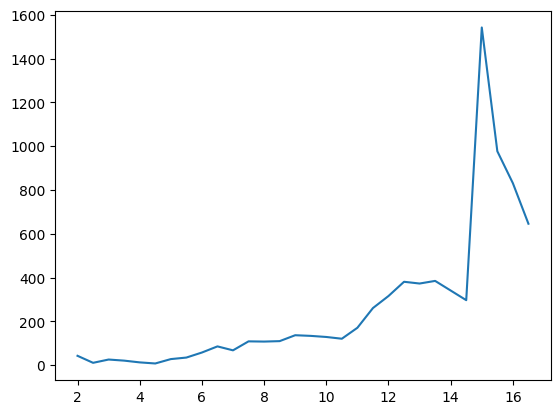

In [29]:
plt.plot(vals[:30], amounts[:30])

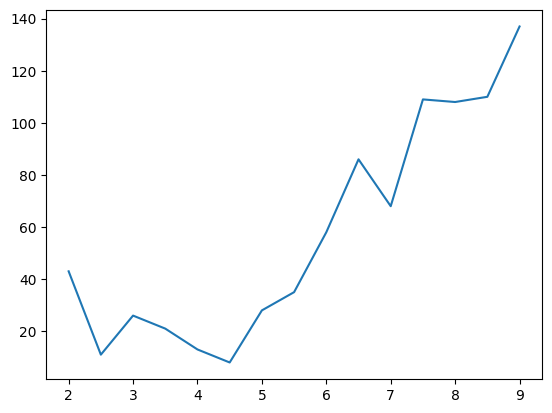

In [30]:
plt.plot(vals[0:15], amounts[0:15])

In [31]:
TRESHOLD = 0.7
df_shortest_distance["spiekkans"] = np.pow((100 - np.pow(df_shortest_distance.distance, 2)).where(lambda val : val > 0, 0) / 100, 2)
df_shortest_distance["spieker"] = (df_shortest_distance["spiekkans"] > TRESHOLD).astype(int)
potential_spiekers = df_shortest_distance[df_shortest_distance.spiekkans > TRESHOLD].sort_values("spiekkans", ascending=False)
potential_spiekers.reset_index(drop=True, inplace=True)
potential_spiekers

,TestKey,neighbourKey,distance,minKey,CandidateKeyTestKey,CandidateKeyneighbourKey,CandidateID_left,CandidateID_neighbour,spiekkans,spieker
0,183639,183760,2.000000,183639,1034431,1071761,103443,107176,0.9216,1
1,183641,183675,2.000000,183641,1033721,1114531,103372,111453,0.9216,1
2,183643,183779,2.000000,183643,1034191,1103301,103419,110330,0.9216,1
3,183642,183688,2.000000,183642,1025991,1051001,102599,105100,0.9216,1
4,183647,183707,2.000000,183647,1095011,1099541,109501,109954,0.9216,1
...,...,...,...,...,...,...,...,...,...,...
101,220397,220377,3.872983,220377,36744021,37482411,3674402,3748241,0.7225,1
102,220377,220397,3.872983,220377,37482411,36744021,3748241,3674402,0.7225,1
103,183663,183846,4.000000,183663,1094041,1107261,109404,110726,0.7056,1
104,202192,202137,4.000000,202137,29599971,29597441,2959997,2959744,0.7056,1


In [ ]:
# DF = POTENTIAL SPIEKERS
random_line = 3
testkeys = potential_spiekers.iloc[random_line][["TestKey", "neighbourKey"]].astype(int).tolist()
dist = potential_spiekers.iloc[random_line]["distance"]
print(testkeys), print(f"dist: {dist}, total_difference: {np.round(dist*dist)}")
df.loc[testkeys, (df.loc[testkeys] != 0).any(axis=0)]

[183642, 183688]
dist: 2.0, total_difference: 4.0


,Q1_A1_norm,Q1_A2_norm,Q1_A3_norm,Q1_A4_norm,Q1_A5_norm,Q1_A1_ips,Q1_A2_ips,Q1_A3_ips,Q1_A4_ips,Q1_A5_ips
TestKey,,,,,,,,,,
183642,4.0,3.0,1.0,2.0,5.0,4.0,3.0,1.0,2.0,5.0
183688,4.0,3.0,2.0,1.0,5.0,4.0,2.0,1.0,3.0,5.0


In [ ]:
# DF = POTENTIAL SPIEKERS
random_line = -1
testkeys = potential_spiekers.iloc[random_line][["TestKey", "neighbourKey"]].astype(int).tolist()
dist = potential_spiekers.iloc[random_line]["distance"]
print(testkeys), print(f"dist: {dist}, total_difference: {np.round(dist*dist)}") 
df.loc[testkeys, (df.loc[testkeys] != 0).any(axis=0)]

[202137, 202192]
dist: 4.0, total_difference: 16.0


,Q51_A1_norm,Q51_A2_norm,Q51_A3_norm,Q51_A4_norm,Q51_A5_norm,Q51_A1_ips,Q51_A2_ips,Q51_A3_ips,Q51_A4_ips,Q51_A5_ips,DaysAgo,VersionNumber_v2.0
TestKey,,,,,,,,,,,,
202137,2.0,1.0,3.0,4.0,5.0,1.0,4.0,3.0,2.0,5.0,3766,10
202192,3.0,1.0,4.0,2.0,5.0,1.0,2.0,4.0,3.0,5.0,3764,10


In [50]:
# DF = df_shortest_distance
random_line = np.round(0.11 * len(df), 0).astype(int)
testkeys = df_shortest_distance.iloc[random_line][["TestKey", "neighbourKey"]].astype(int).tolist()
dist = df_shortest_distance.iloc[random_line]["distance"]
print(testkeys), print(f"dist: {dist}, total_difference: {np.round(dist*dist)}") 
df.loc[testkeys, (df.loc[testkeys] != 0).any(axis=0)]

[206924, 206658]
dist: 16.24807680927192, total_difference: 264.0


,Q2_A1_norm,Q2_A2_norm,Q2_A3_norm,Q2_A4_norm,Q2_A5_norm,Q7_A1_norm,Q7_A2_norm,Q7_A3_norm,Q7_A4_norm,Q7_A5_norm,Q51_A1_norm,Q51_A2_norm,Q51_A3_norm,Q51_A4_norm,Q51_A5_norm,Q2_A1_ips,Q2_A2_ips,Q2_A3_ips,Q2_A4_ips,Q2_A5_ips,Q7_A1_ips,Q7_A2_ips,Q7_A3_ips,Q7_A4_ips,Q7_A5_ips,Q51_A1_ips,Q51_A2_ips,Q51_A3_ips,Q51_A4_ips,Q51_A5_ips,DaysAgo,VersionNumber_v2.0
TestKey,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
206924,1.0,4.0,3.0,2.0,5.0,4.0,5.0,3.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,3.0,2.0,5.0,4.0,5.0,3.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,3359,10
206658,1.0,5.0,3.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,1.0,3.0,5.0,1.0,5.0,3.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,1.0,3.0,5.0,3363,10


In [47]:
# DF = df_shortest_distance
random_line = np.round(0.77 * len(df), 0).astype(int)
print(random_line), len(df)
testkeys = df_shortest_distance.iloc[random_line][["TestKey", "neighbourKey"]].astype(int).tolist()
dist = df_shortest_distance.iloc[random_line]["distance"]
print(testkeys), print(f"dist: {dist}, total_difference: {np.round(dist*dist)}") 
df.loc[testkeys, (df.loc[testkeys] != 0).any(axis=0)]

16319
[237998, 247395]
dist: 32.49615361854384, total_difference: 1056.0


,Q1_A1_norm,Q1_A2_norm,Q1_A3_norm,Q1_A4_norm,Q1_A5_norm,Q2_A1_norm,Q2_A2_norm,Q2_A3_norm,Q2_A4_norm,Q2_A5_norm,Q3_A1_norm,Q3_A2_norm,Q3_A3_norm,Q3_A4_norm,Q3_A5_norm,Q6_A1_norm,Q6_A2_norm,Q6_A3_norm,Q6_A4_norm,Q6_A5_norm,Q7_A1_norm,Q7_A2_norm,Q7_A3_norm,Q7_A4_norm,Q7_A5_norm,Q8_A1_norm,Q8_A2_norm,Q8_A3_norm,Q8_A4_norm,Q8_A5_norm,Q11_A1_norm,Q11_A2_norm,Q11_A3_norm,Q11_A4_norm,Q11_A5_norm,Q12_A1_norm,Q12_A2_norm,Q12_A3_norm,Q12_A4_norm,Q12_A5_norm,Q13_A1_norm,Q13_A2_norm,Q13_A3_norm,Q13_A4_norm,Q13_A5_norm,Q16_A1_norm,Q16_A2_norm,Q16_A3_norm,Q16_A4_norm,Q16_A5_norm,Q17_A1_norm,Q17_A2_norm,Q17_A3_norm,Q17_A4_norm,Q17_A5_norm,Q18_A1_norm,Q18_A2_norm,Q18_A3_norm,Q18_A4_norm,Q18_A5_norm,Q21_A1_norm,Q21_A2_norm,Q21_A3_norm,Q21_A4_norm,Q21_A5_norm,Q22_A1_norm,Q22_A2_norm,Q22_A3_norm,Q22_A4_norm,Q22_A5_norm,Q26_A1_norm,Q26_A2_norm,Q26_A3_norm,Q26_A4_norm,Q26_A5_norm,Q27_A1_norm,Q27_A2_norm,Q27_A3_norm,Q27_A4_norm,Q27_A5_norm,Q31_A1_norm,Q31_A2_norm,Q31_A3_norm,Q31_A4_norm,Q31_A5_norm,Q32_A1_norm,Q32_A2_norm,Q32_A3_norm,Q32_A4_norm,Q32_A5_norm,Q36_A1_norm,Q36_A2_norm,Q36_A3_norm,Q36_A4_norm,Q36_A5_norm,Q37_A1_norm,Q37_A2_norm,Q37_A3_norm,Q37_A4_norm,Q37_A5_norm,Q41_A1_norm,Q41_A2_norm,Q41_A3_norm,Q41_A4_norm,Q41_A5_norm,Q42_A1_norm,Q42_A2_norm,Q42_A3_norm,Q42_A4_norm,Q42_A5_norm,Q46_A1_norm,Q46_A2_norm,Q46_A3_norm,Q46_A4_norm,Q46_A5_norm,Q47_A1_norm,Q47_A2_norm,Q47_A3_norm,Q47_A4_norm,Q47_A5_norm,Q51_A1_norm,Q51_A2_norm,Q51_A3_norm,Q51_A4_norm,Q51_A5_norm,Q52_A1_norm,Q52_A2_norm,Q52_A3_norm,Q52_A4_norm,Q52_A5_norm,Q56_A1_norm,Q56_A2_norm,Q56_A3_norm,Q56_A4_norm,Q56_A5_norm,Q57_A1_norm,Q57_A2_norm,Q57_A3_norm,Q57_A4_norm,Q57_A5_norm,Q61_A1_norm,Q61_A2_norm,Q61_A3_norm,Q61_A4_norm,Q61_A5_norm,Q62_A1_norm,Q62_A2_norm,Q62_A3_norm,Q62_A4_norm,Q62_A5_norm,Q1_A1_ips,Q1_A2_ips,Q1_A3_ips,Q1_A4_ips,Q1_A5_ips,Q2_A1_ips,Q2_A2_ips,Q2_A3_ips,Q2_A4_ips,Q2_A5_ips,Q3_A1_ips,Q3_A2_ips,Q3_A3_ips,Q3_A4_ips,Q3_A5_ips,Q6_A1_ips,Q6_A2_ips,Q6_A3_ips,Q6_A4_ips,Q6_A5_ips,Q7_A1_ips,Q7_A2_ips,Q7_A3_ips,Q7_A4_ips,Q7_A5_ips,Q8_A1_ips,Q8_A2_ips,Q8_A3_ips,Q8_A4_ips,Q8_A5_ips,Q11_A1_ips,Q11_A2_ips,Q11_A3_ips,Q11_A4_ips,Q11_A5_ips,Q12_A1_ips,Q12_A2_ips,Q12_A3_ips,Q12_A4_ips,Q12_A5_ips,Q13_A1_ips,Q13_A2_ips,Q13_A3_ips,Q13_A4_ips,Q13_A5_ips,Q16_A1_ips,Q16_A2_ips,Q16_A3_ips,Q16_A4_ips,Q16_A5_ips,Q17_A1_ips,Q17_A2_ips,Q17_A3_ips,Q17_A4_ips,Q17_A5_ips,Q18_A1_ips,Q18_A2_ips,Q18_A3_ips,Q18_A4_ips,Q18_A5_ips,Q21_A1_ips,Q21_A2_ips,Q21_A3_ips,Q21_A4_ips,Q21_A5_ips,Q22_A1_ips,Q22_A2_ips,Q22_A3_ips,Q22_A4_ips,Q22_A5_ips,Q26_A1_ips,Q26_A2_ips,Q26_A3_ips,Q26_A4_ips,Q26_A5_ips,Q27_A1_ips,Q27_A2_ips,Q27_A3_ips,Q27_A4_ips,Q27_A5_ips,Q31_A1_ips,Q31_A2_ips,Q31_A3_ips,Q31_A4_ips,Q31_A5_ips,Q32_A1_ips,Q32_A2_ips,Q32_A3_ips,Q32_A4_ips,Q32_A5_ips,Q36_A1_ips,Q36_A2_ips,Q36_A3_ips,Q36_A4_ips,Q36_A5_ips,Q37_A1_ips,Q37_A2_ips,Q37_A3_ips,Q37_A4_ips,Q37_A5_ips,Q41_A1_ips,Q41_A2_ips,Q41_A3_ips,Q41_A4_ips,Q41_A5_ips,Q42_A1_ips,Q42_A2_ips,Q42_A3_ips,Q42_A4_ips,Q42_A5_ips,Q46_A1_ips,Q46_A2_ips,Q46_A3_ips,Q46_A4_ips,Q46_A5_ips,Q47_A1_ips,Q47_A2_ips,Q47_A3_ips,Q47_A4_ips,Q47_A5_ips,Q51_A1_ips,Q51_A2_ips,Q51_A3_ips,Q51_A4_ips,Q51_A5_ips,Q52_A1_ips,Q52_A2_ips,Q52_A3_ips,Q52_A4_ips,Q52_A5_ips,Q56_A1_ips,Q56_A2_ips,Q56_A3_ips,Q56_A4_ips,Q56_A5_ips,Q57_A1_ips,Q57_A2_ips,Q57_A3_ips,Q57_A4_ips,Q57_A5_ips,Q61_A1_ips,Q61_A2_ips,Q61_A3_ips,Q61_A4_ips,Q61_A5_ips,Q62_A1_ips,Q62_A2_ips,Q62_A3_ips,Q62_A4_ips,Q62_A5_ips,DaysAgo,VersionNumber_v2.1
TestKey,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
237998,5.0,3.0,1.0,4.0,2.0,4.0,3.0,5.0,1.0,2.0,2.0,5.0,3.0,4.0,1.0,1.0,3.0,4.0,5.0,2.0,1.0,5.0,4.0,2.0,3.0,4.0,3.0,5.0,1.0,2.0,1.0,4.0,3.0,5.0,2.0,5.0,1.0,3.0,2.0,4.0,2.0,1.0,4.0,3.0,5.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,1.0,5.0,4.0,2.0,5.0,1.0,3.0,4.0,3.0,5.0,2.0,1.0,4.0,2.0,3

## Conclusion DF's

In [36]:
df_distance_null_same_candidates

,TestKey,neighbourKey,distance,minKey,CandidateKeyTestKey,CandidateKeyneighbourKey,CandidateID_left,CandidateID_neighbour


In [37]:
df_distance_null_diff_candidates

,TestKey,neighbourKey,distance,minKey,CandidateKeyTestKey,CandidateKeyneighbourKey,CandidateID_left,CandidateID_neighbour


In [38]:
df_shortest_distance

,TestKey,neighbourKey,distance,minKey,CandidateKeyTestKey,CandidateKeyneighbourKey,CandidateID_left,CandidateID_neighbour,spiekkans,spieker
0,183639,183760,2.000000,183639,1034431,1071761,103443,107176,0.9216,1
1,183640,183675,2.449490,183640,1034091,1114531,103409,111453,0.8836,1
2,183641,183675,2.000000,183641,1033721,1114531,103372,111453,0.9216,1
3,183642,183688,2.000000,183642,1025991,1051001,102599,105100,0.9216,1
4,183643,183779,2.000000,183643,1034191,1103301,103419,110330,0.9216,1
...,...,...,...,...,...,...,...,...,...,...
21189,255089,255063,5.830952,255063,45636285,45630165,4563628,4563016,0.4356,0
21190,255095,254980,16.673332,254980,45640415,45607505,4564041,4560750,0.0000,0
21191,255098,254990,17.378147,254990,45641655,45610845,4564165,4561084,0.0000,0
21192,255099,241869,19.261360,241869,45644685,50784381,4564468,5078438,0.0000,0


In [39]:
# to csv
df_distance_null_same_candidates.to_csv("../csv/neighbours_afstand_0_same_candidateID.csv", index=False)
df_distance_null_diff_candidates.to_csv("../csv/neighbours_afstand_0_diff_candidateID.csv", index=False)
df_shortest_distance.to_csv("../csv/neighbours.csv", index=False)

In [40]:
print(len(df) == len(df_shortest_distance))

True
